#  Ghép ảnh toàn cảnh (Panoramic Photos– Image Stitching)

## Load và tiền xử lý ảnh

### Import

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import requests

image_folder = "images"

if not os.path.exists(image_folder):
    os.makedirs(image_folder)
    print(f"Created folder: {image_folder}")

Created folder: images


### Load ảnh

In [2]:
image_paths = [
    "images/20240409_095557.jpg",
    "images/20240409_095602.jpg",
    "images/20240409_095607.jpg",
    "images/20240409_095613.jpg"
]

images = []
grays = []

for path in image_paths:
    img = cv2.imread(path)
    img = cv2.resize(img, (1200, 800))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    images.append(img)
    grays.append(gray)

## FEATURE EXTRACTION

In [3]:
def extract_features(gray, method="SIFT"):
    if method == "SIFT":
        detector = cv2.SIFT_create()
    elif method == "ORB":
        detector = cv2.ORB_create()
    elif method == "SURF":
        try:
            detector = cv2.xfeatures2d.SURF_create(400)
        except:
            detector = cv2.SIFT_create()

    kp, des = detector.detectAndCompute(gray, None)
    return kp, des

## FEATURE MATCHING

In [4]:
def match_features(des1, des2, method="SIFT"):

    if method == "ORB":
        bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    else:
        bf = cv2.BFMatcher()

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return good

## TÍNH HOMOGRAPHY

In [5]:
def compute_homography(kp1, kp2, matches):

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

    H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    return H

## WARP + STITCH

In [6]:
def warp_and_stitch(img1, img2, H):

    h2, w2 = img2.shape[:2]

    result = cv2.warpPerspective(img1, H, (w2 + img1.shape[1], h2))

    result[0:h2, 0:w2] = img2

    return result

## BLENDING (cơ bản)

In [7]:
def simple_blending(result, img2):

    h2, w2 = img2.shape[:2]

    for i in range(h2):
        for j in range(w2):
            if np.sum(result[i,j]) == 0:
                result[i,j] = img2[i,j]

    return result

## Ghép Ảnh

In [8]:
def panorama(images, method="SIFT"):

    pano = images[0]

    for i in range(1, len(images)):

        gray1 = cv2.cvtColor(pano, cv2.COLOR_RGB2GRAY)
        gray2 = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY)

        # 1. Feature
        kp1, des1 = extract_features(gray1, method)
        kp2, des2 = extract_features(gray2, method)

        # 2. Matching
        matches = match_features(des1, des2, method)

        if len(matches) < 10:
            print("Not enough matches")
            continue

        # 3. Homography
        H = compute_homography(kp1, kp2, matches)

        # 4. Warp + Stitch
        pano = warp_and_stitch(pano, images[i], H)

        # 5. Blending
        pano = simple_blending(pano, images[i])

    return pano

## Chạy 3 Phương Pháp

In [9]:
pano_sift = panorama(images, "SIFT")
pano_orb  = panorama(images, "ORB")
pano_surf = panorama(images, "SURF")

Not enough matches


## Hiển Thị

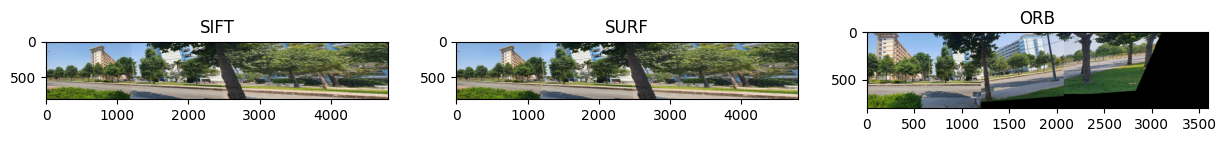

In [10]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(pano_sift)
plt.title("SIFT")

plt.subplot(1,3,2)
plt.imshow(pano_surf)
plt.title("SURF")

plt.subplot(1,3,3)
plt.imshow(pano_orb)
plt.title("ORB")

plt.show()